# Steam Games EDA


In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

from kaggle_games.split_data import get_split_data

## Data loading


In [2]:
data_path = Path.cwd().parent / "data" / "games.json"

df = pd.read_json(data_path, orient="index")
df.replace(r"^\s*$", np.nan, regex=True, inplace=True)

pd.set_option("display.max_columns", None)

print(f"Columns loaded: {len(df.columns)}")
print(f"Rows loaded: {len(df)}")
print(df.head())

Columns loaded: 42
Rows loaded: 122611
                                          name  release_date  required_age  \
2539430             Black Dragon Mage Playtest   Aug 1, 2023             0   
496350   Supipara - Chapter 1 Spring Has Come!  Jul 29, 2016             0   
1034400      Mystery Solitaire The Black Raven   May 6, 2019             0   
3292190            버튜버 파라노이아 - Vtuber Paranoia  Oct 31, 2024             0   
3631080                          Maze Quest VR  Apr 24, 2025             0   

         price  dlc_count                               detailed_description  \
2539430   0.00          0                                                NaN   
496350    5.24          0  Springtime, April: when the cherry trees come ...   
1034400   4.99          0  Immerse yourself in the most beloved, mystical...   
3292190   8.99          1  synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...   
3631080   4.99          0  Its not just a Maze; its a Quest! Enter the ca...   

           

## Train-test split


In [3]:
X_train, X_test, y_train, y_test = get_split_data(df)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (98088, 39)
Test set shape: (24523, 39)


## Analysis


### Missing values


In [4]:
print(X_train.isna().sum() / len(X_train))

name                        0.000010
release_date                0.000000
required_age                0.000000
price                       0.000000
dlc_count                   0.000000
detailed_description        0.069162
about_the_game              0.069407
short_description           0.068214
reviews                     0.902037
header_image                0.000683
website                     0.594935
support_url                 0.558254
support_email               0.182418
windows                     0.000000
mac                         0.000000
linux                       0.000000
metacritic_score            0.000000
metacritic_url              0.965164
achievements                0.000000
recommendations             0.000000
notes                       0.816175
supported_languages         0.000000
full_audio_languages        0.000000
packages                    0.000000
developers                  0.000000
publishers                  0.000000
categories                  0.000000
g

In [5]:
df_train = X_train.copy()
df_train["is_hit"] = y_train

features = df_train.drop(columns=["is_hit"])
target = df_train["is_hit"]

is_missing = features.isna()
is_present = features.notna()

hits_missing = is_missing.T.dot(target)
hits_present = is_present.T.dot(target)

missing_counts = is_missing.sum()
present_counts = is_present.sum()

summary = pd.DataFrame(
    {
        "Missing_Count": missing_counts,
        "Present_Count": present_counts,
        "Hit_Rate_NaN_%": (hits_missing / missing_counts.replace(0, np.nan))
        * 100,
        "Hit_Rate_Present_%": (hits_present / present_counts.replace(0, np.nan))
        * 100,
    }
)

summary = summary[
    (summary["Missing_Count"] > 0) & (summary["Present_Count"] > 0)
].copy()

summary["Difference_pp"] = (
    summary["Hit_Rate_Present_%"] - summary["Hit_Rate_NaN_%"]
)
summary = summary.sort_values(by="Difference_pp", key=abs, ascending=False)

print(summary)

                      Missing_Count  Present_Count Hit_Rate_NaN_%  \
metacritic_url                94671           3417       2.547771   
reviews                       88479           9609       2.695555   
website                       58356          39732       1.648502   
short_description              6691          91397            0.0   
detailed_description           6784          91304       0.191627   
about_the_game                 6808          91280       0.249706   
score_rank                    98056             32       3.848821   
name                              1          98087            0.0   
support_url                   54758          43330       2.158589   
support_email                 17893          80195       6.175599   
notes                         80057          18031       3.683625   
header_image                     67          98021       2.985075   

                     Hit_Rate_Present_% Difference_pp  
metacritic_url                39.859526     37

In [6]:
print(df_train[~df_train["score_rank"].isna()])

                                                      name  release_date  \
603120                                       Happy Campers  Apr 10, 2017   
608510                    You Must be 18 or Older to Enter  Oct 30, 2017   
823550                                         Booty Calls  Sep 18, 2018   
502300                              Heartomics: Lost Count  Nov 26, 2016   
592750                                        SPACE-FRIGHT   Mar 3, 2017   
726360               BOOBS SAGA: Prepare To Hentai Edition  May 22, 2020   
929300                          Chroma : Sexy Hentai Girls   Oct 2, 2018   
896890                         VR Paradise - Steam Edition  Dec 23, 2019   
560000                                Ladykiller in a Bind   Jan 9, 2017   
929290                        Strip Breaker : Hentai Girls  Sep 30, 2018   
961640                            The Tower of Five Hearts  Nov 14, 2018   
975020   The Spirit Master of Retarnia -Conqueror of th...   Dec 6, 2018   
891870      

In [7]:
X_train = X_train.dropna(subset=["name"])
y_train = y_train.loc[X_train.index]

In [8]:
mnar_columns = [
    "metacritic_url",
    "reviews",
    "website",
    "support_url",
    "support_email",
    "short_description",
    "detailed_description",
    "about_the_game",
    "score_rank",
]

for col in mnar_columns:
    X_train[f"has_{col}"] = X_train[col].notna().astype(int)

X_train = X_train.drop(columns=mnar_columns)

print(X_train[[f"has_{col}" for col in mnar_columns]].head())

         has_metacritic_url  has_reviews  has_website  has_support_url  \
943810                    0            0            1                0   
1287710                   0            0            0                0   
397840                    0            0            0                0   
2211190                   0            1            1                1   
2124300                   0            0            1                0   

         has_support_email  has_short_description  has_detailed_description  \
943810                   1                      1                         1   
1287710                  1                      1                         1   
397840                   1                      1                         1   
2211190                  1                      1                         1   
2124300                  1                      1                         1   

         has_about_the_game  has_score_rank  
943810                    1       

In [9]:
cols_to_drop = ["header_image", "notes"]

X_train = X_train.drop(columns=cols_to_drop)

In [10]:
print(X_train.isna().sum() / len(X_train))

name                        0.0
release_date                0.0
required_age                0.0
price                       0.0
dlc_count                   0.0
windows                     0.0
mac                         0.0
linux                       0.0
metacritic_score            0.0
achievements                0.0
recommendations             0.0
supported_languages         0.0
full_audio_languages        0.0
packages                    0.0
developers                  0.0
publishers                  0.0
categories                  0.0
genres                      0.0
screenshots                 0.0
movies                      0.0
user_score                  0.0
average_playtime_forever    0.0
average_playtime_2weeks     0.0
median_playtime_forever     0.0
median_playtime_2weeks      0.0
discount                    0.0
peak_ccu                    0.0
tags                        0.0
has_metacritic_url          0.0
has_reviews                 0.0
has_website                 0.0
has_supp

### Data types and distributions


In [11]:
print(X_train.dtypes)

name                            str
release_date                    str
required_age                  int64
price                       float64
dlc_count                     int64
windows                        bool
mac                            bool
linux                          bool
metacritic_score              int64
achievements                  int64
recommendations               int64
supported_languages          object
full_audio_languages         object
packages                     object
developers                   object
publishers                   object
categories                   object
genres                       object
screenshots                  object
movies                       object
user_score                    int64
average_playtime_forever      int64
average_playtime_2weeks       int64
median_playtime_forever       int64
median_playtime_2weeks        int64
discount                      int64
peak_ccu                      int64
tags                        

In [ ]:
cols_to_drop = ["name", "developers", "publishers", "screenshots", "movies"]
X_train = X_train.drop(columns=cols_to_drop)

In [13]:
print(X_train.dtypes)

release_date                    str
required_age                  int64
price                       float64
dlc_count                     int64
windows                        bool
mac                            bool
linux                          bool
metacritic_score              int64
achievements                  int64
recommendations               int64
supported_languages          object
full_audio_languages         object
packages                     object
categories                   object
genres                       object
user_score                    int64
average_playtime_forever      int64
average_playtime_2weeks       int64
median_playtime_forever       int64
median_playtime_2weeks        int64
discount                      int64
peak_ccu                      int64
tags                         object
has_metacritic_url            int64
has_reviews                   int64
has_website                   int64
has_support_url               int64
has_support_email           

In [ ]:
X_train["release_date"] = pd.to_datetime(
    X_train["release_date"], errors="coerce"
)
X_train["release_year"] = X_train["release_date"].dt.year.fillna(0).astype(int)
X_train["release_month"] = (
    X_train["release_date"].dt.month.fillna(0).astype(int)
)

X_train["language_count"] = (
    X_train["supported_languages"].str.len().fillna(0).astype(int)
)
X_train["tag_count"] = X_train["tags"].str.len().fillna(0).astype(int)

categories_str = X_train["categories"].astype(str)
X_train["is_multiplayer"] = categories_str.str.contains(
    "Multiplayer", case=False, na=False
).astype(int)

genres_str = X_train["genres"].astype(str)
X_train["is_free_to_play"] = genres_str.str.contains(
    "Free to Play", case=False, na=False
).astype(int)

cols_to_drop = [
    "release_date",
    "supported_languages",
    "full_audio_languages",
    "packages",
    "developers",
    "publishers",
    "categories",
    "genres",
    "screenshots",
    "movies",
    "tags",
    "name",
    "estimated_owners",
]

X_train = X_train.drop(columns=cols_to_drop, errors="ignore")

print(
    X_train[
        ["language_count", "tag_count", "is_multiplayer", "is_free_to_play"]
    ].head()
)

         language_count  tag_count  is_multiplayer  is_free_to_play
943810                4         20               0                0
1287710              14         20               0                0
397840                6          3               0                0
2211190               1         11               0                0
2124300               1         20               0                0


In [15]:
print(X_train.describe())

       required_age         price     dlc_count  metacritic_score  \
count  98087.000000  98087.000000  98087.000000      98087.000000   
mean       0.169533      4.794327      0.516868          2.572002   
std        1.662069     12.896080     10.440572         13.673206   
min        0.000000      0.000000      0.000000          0.000000   
25%        0.000000      0.550000      0.000000          0.000000   
50%        0.000000      2.240000      0.000000          0.000000   
75%        0.000000      5.240000      0.000000          0.000000   
max       21.000000    999.980000   2006.000000         96.000000   

       achievements  recommendations    user_score  average_playtime_forever  \
count  98087.000000     9.808700e+04  98087.000000              9.808700e+04   
mean      18.072650     9.996298e+02      0.025121              2.208819e+02   
std      139.505061     2.335871e+04      1.429629              1.250198e+04   
min        0.000000     0.000000e+00      0.000000        

In [ ]:
binary_cols = [
    col
    for col in X_train.columns
    if set(X_train[col].dropna().unique()) <= {0, 1}
]

mapping = {0.0: "No", 1.0: "Yes"}

for col in binary_cols:
    X_train[col] = X_train[col].astype(float).map(mapping).astype("category")

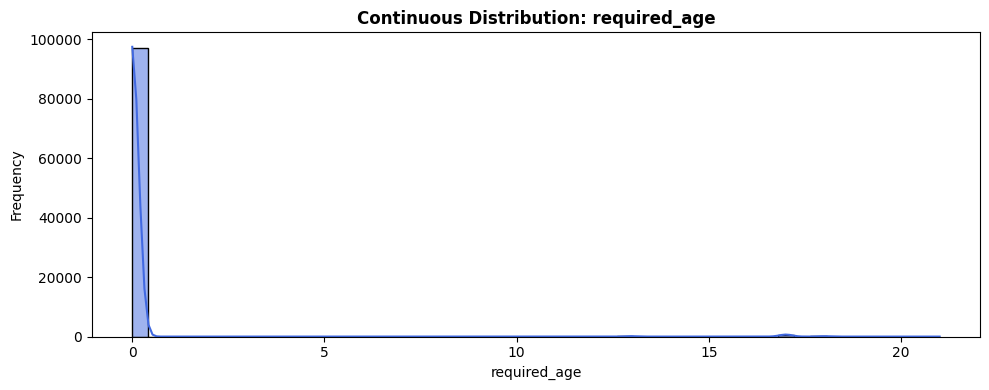

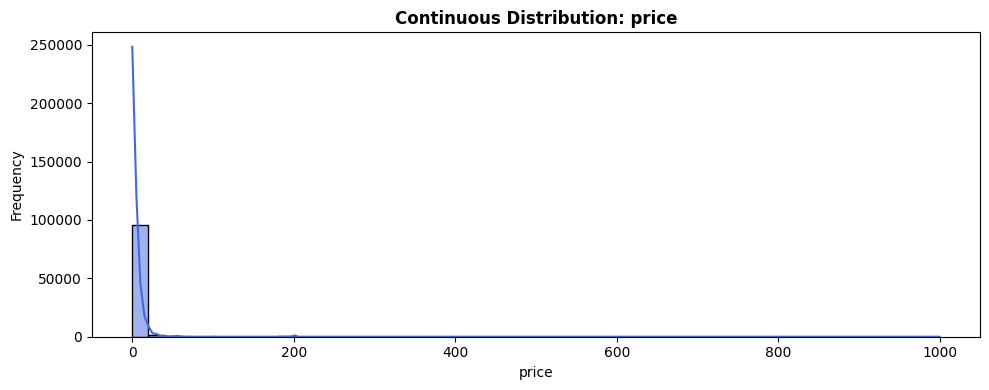

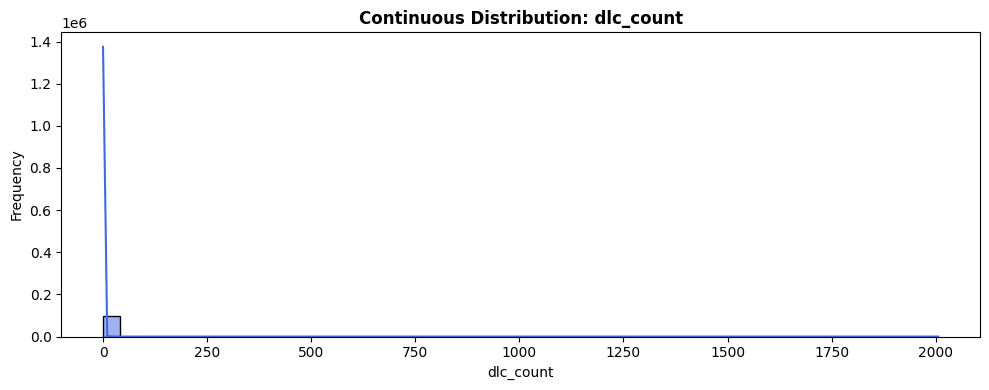

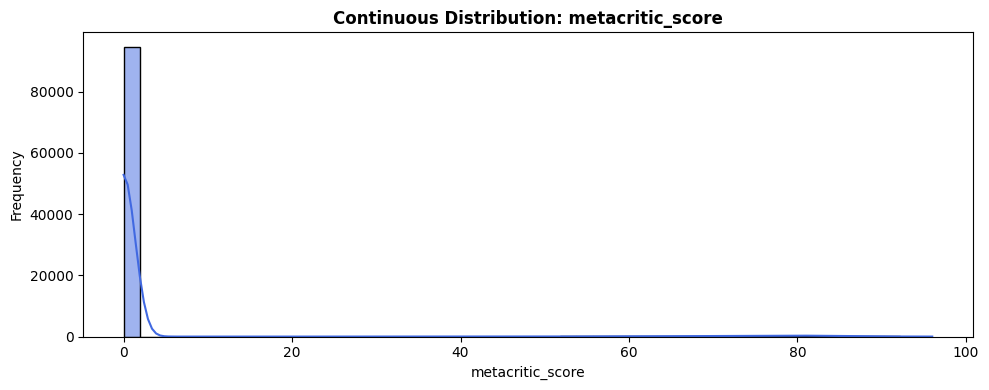

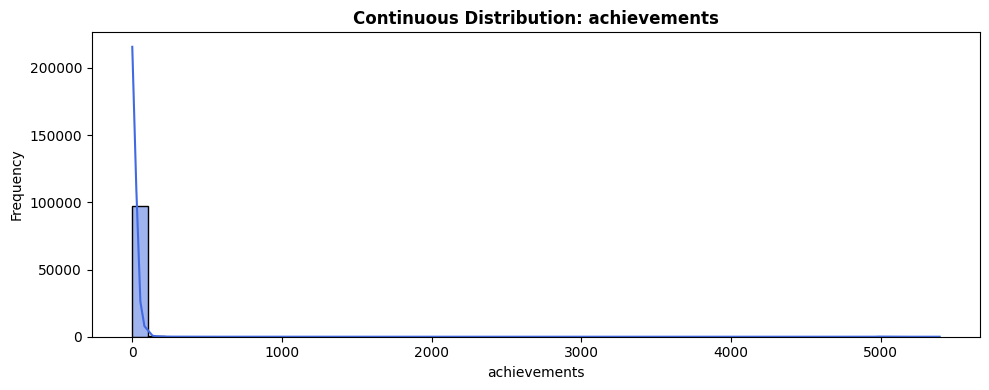

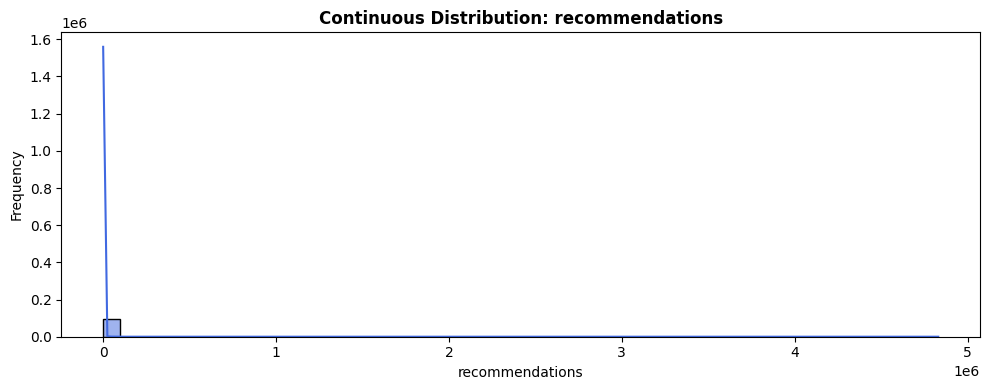

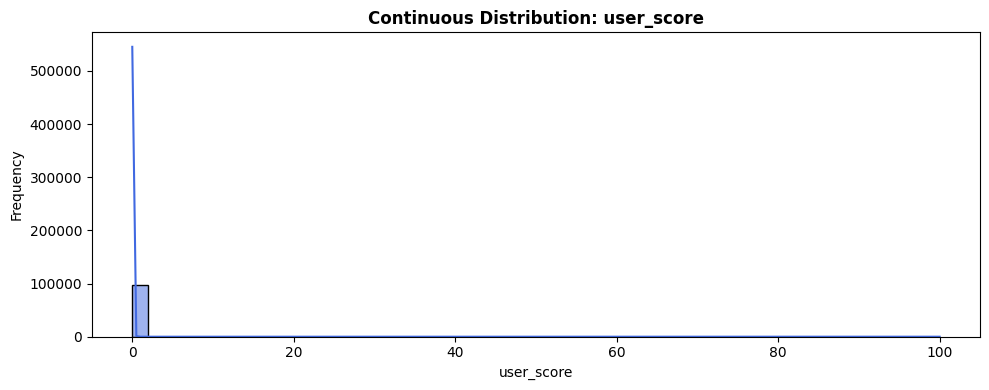

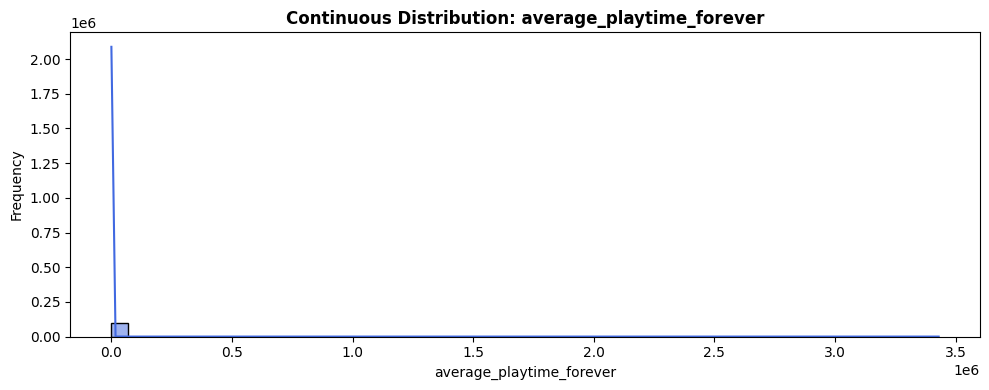

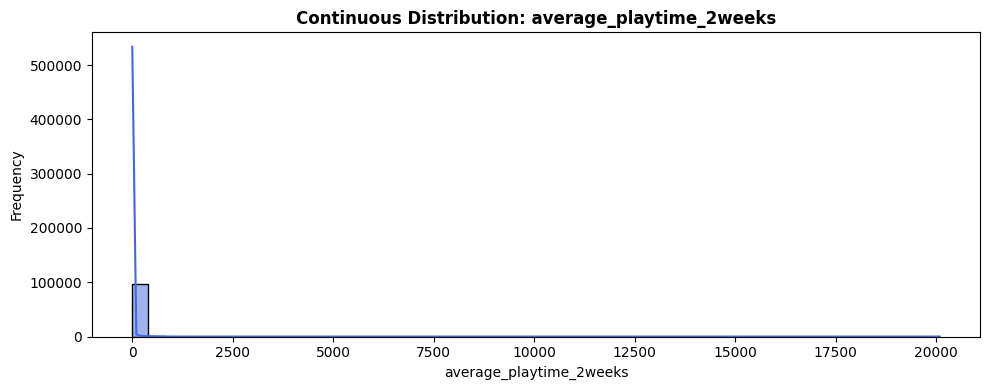

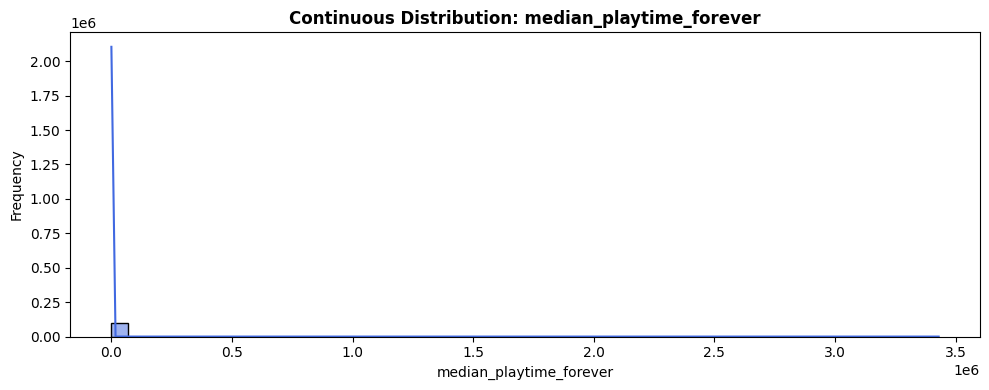

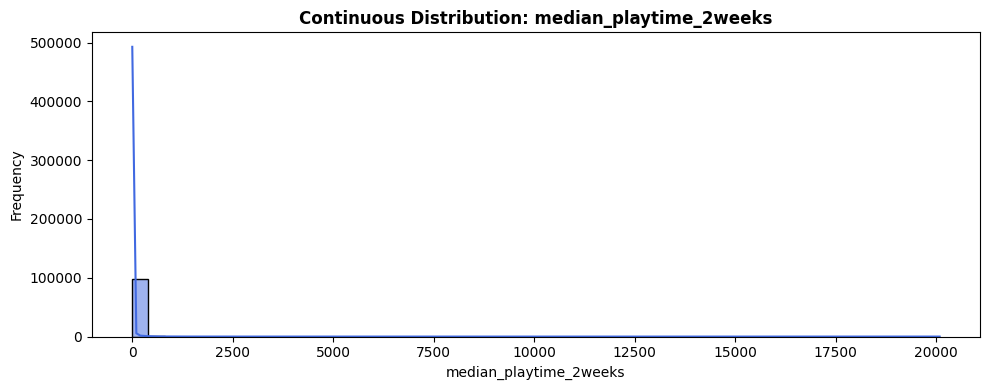

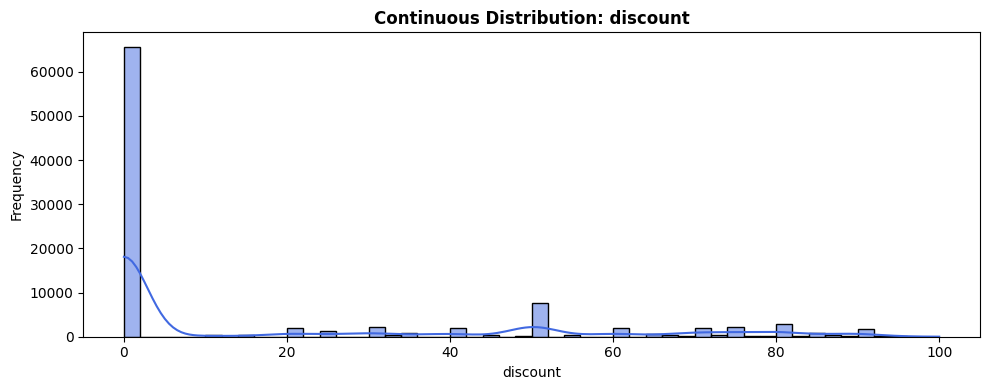

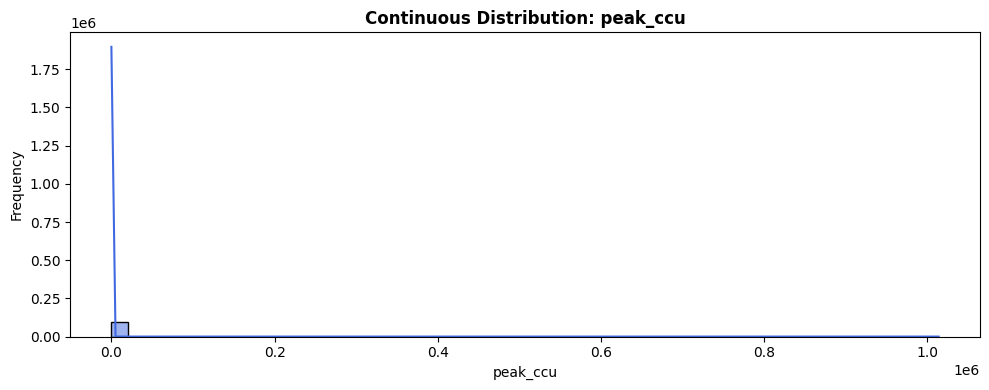

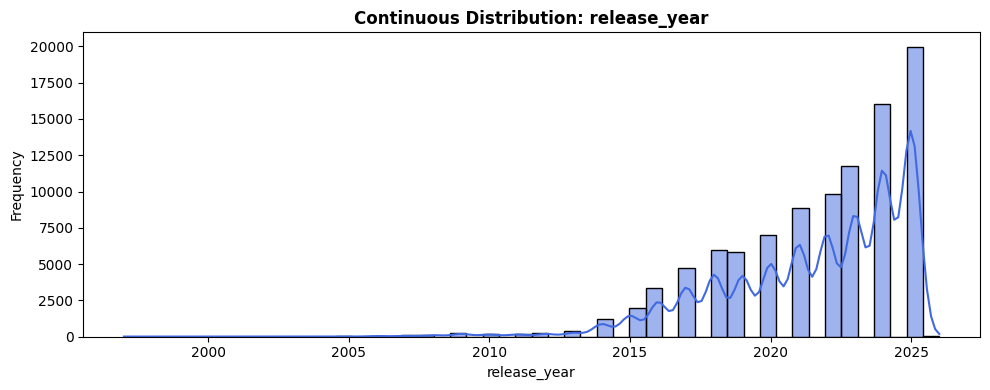

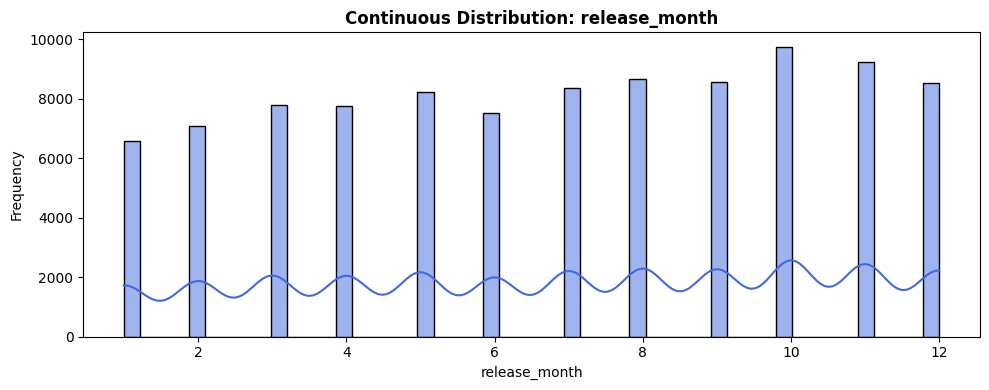

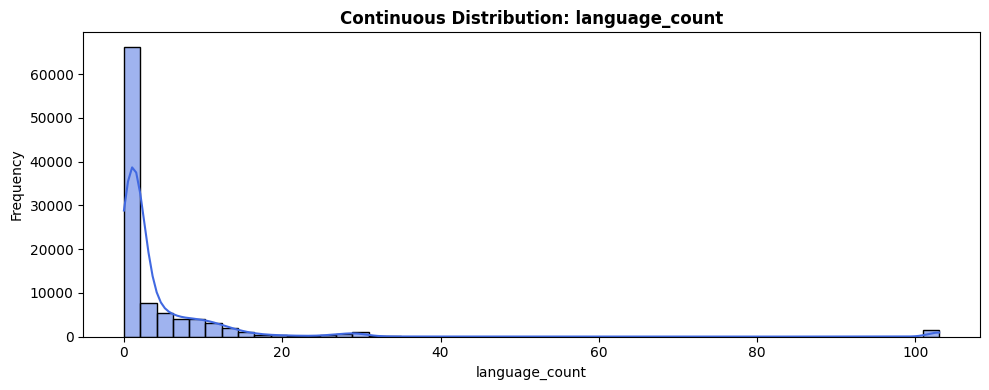

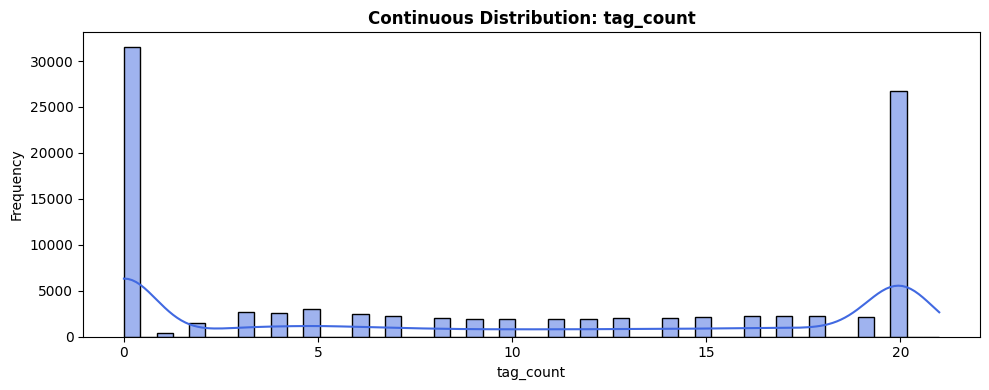

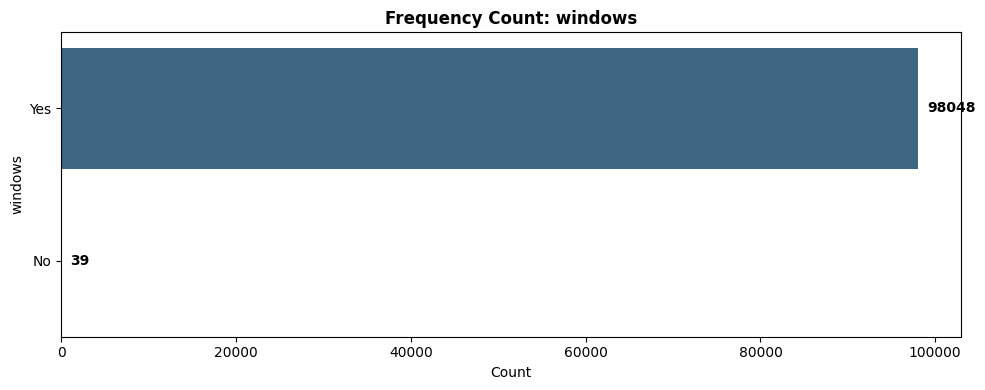

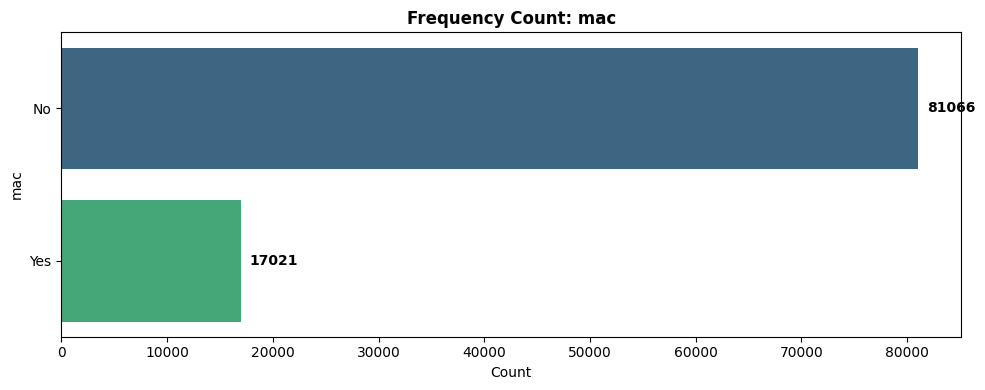

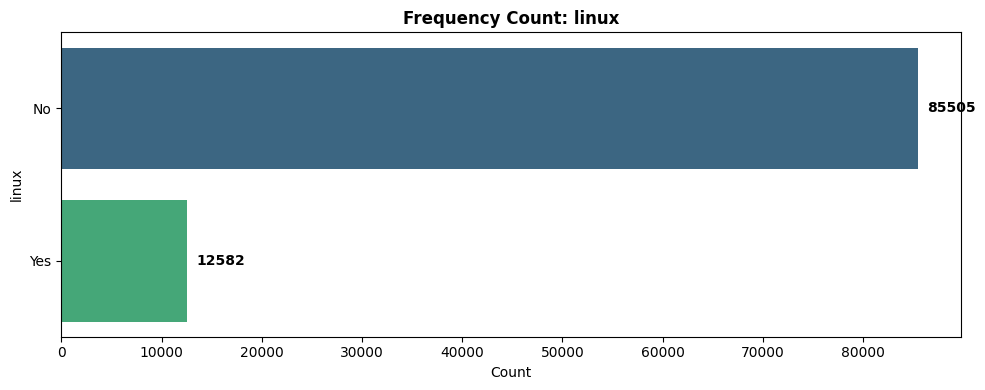

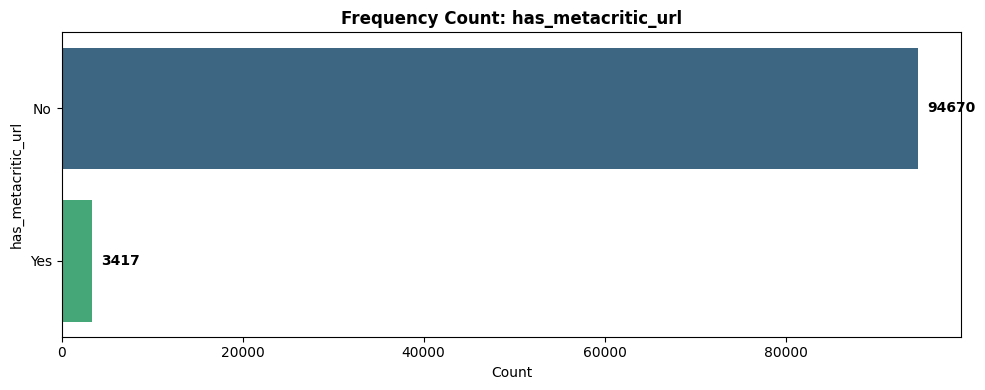

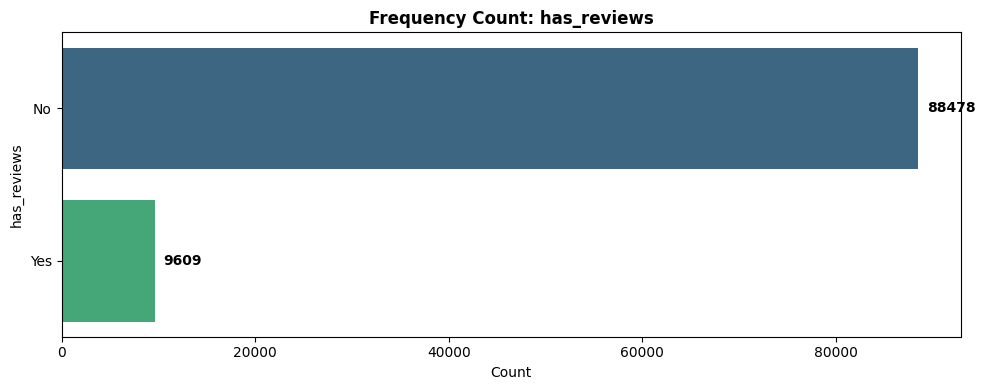

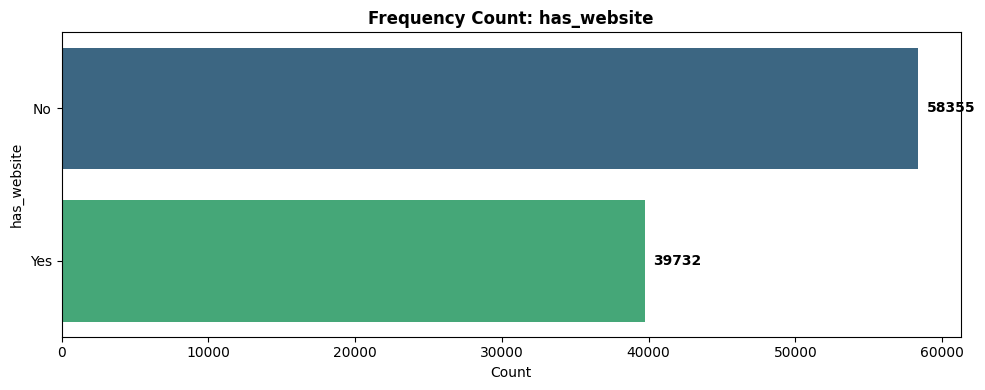

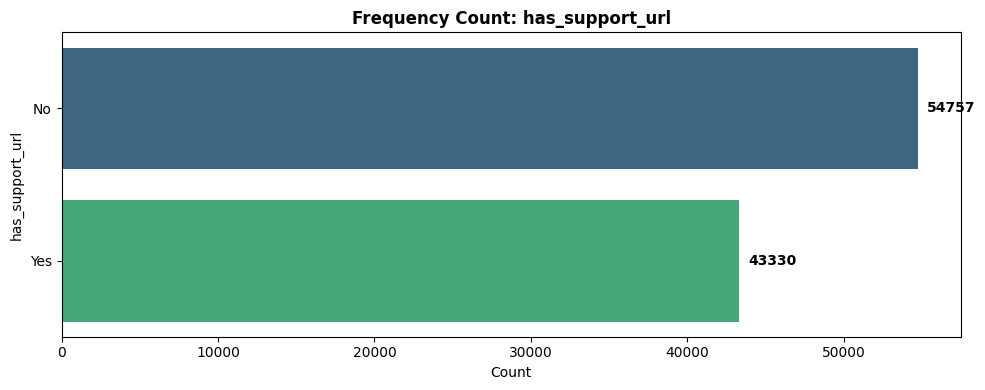

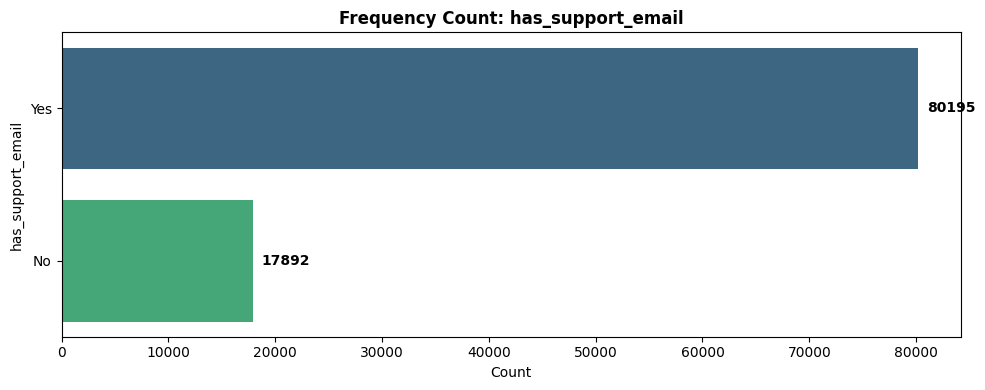

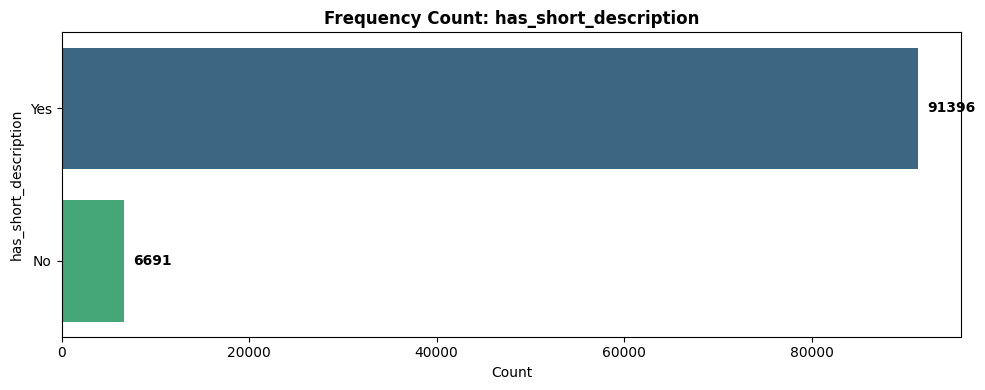

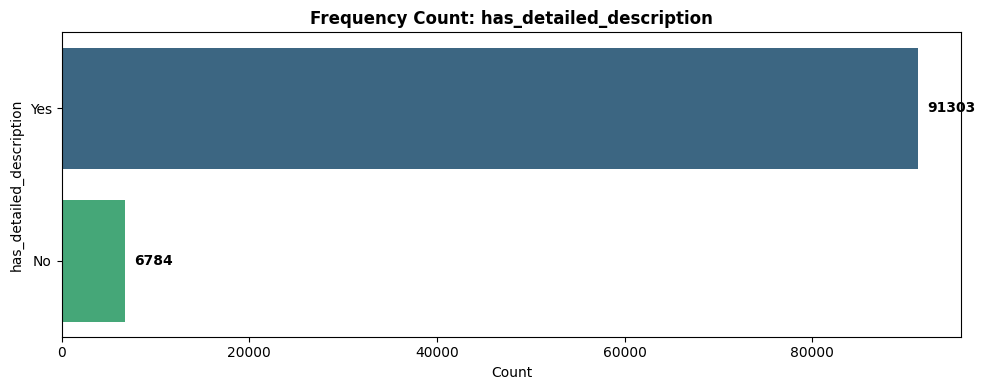

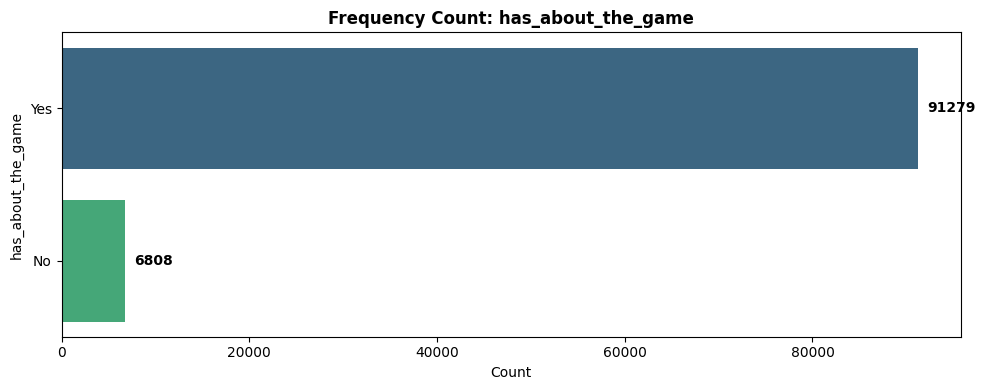

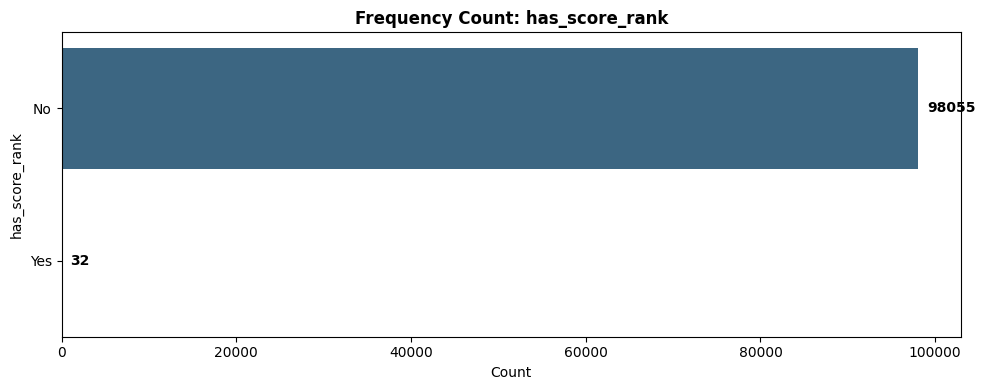

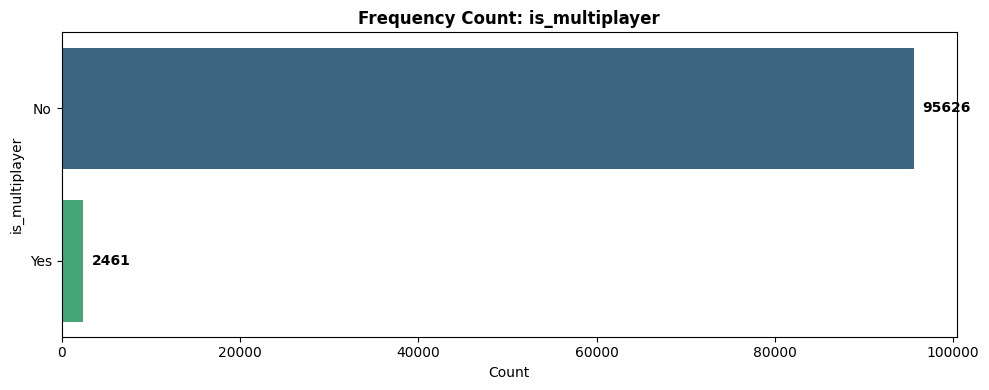

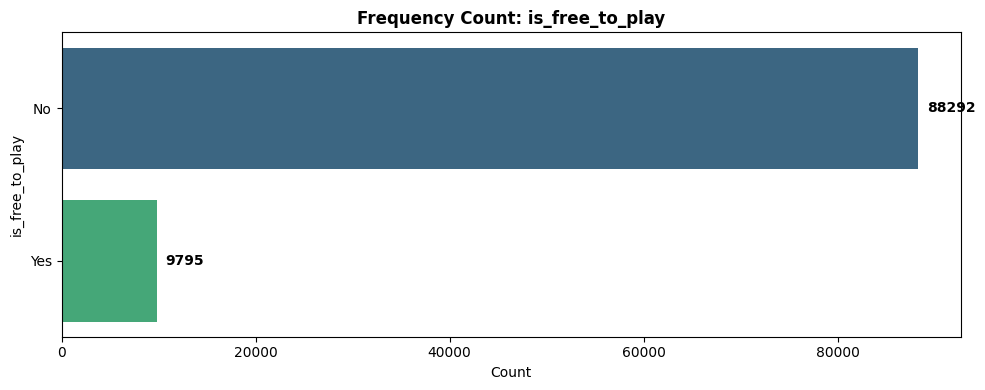

In [ ]:
num_cols = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

continuous_num = [
    col for col in num_cols if X_train[col].nunique(dropna=True) > 10
]
to_plot_discrete = [col for col in X_train.columns if col not in continuous_num]

for col in continuous_num:
    plt.figure(figsize=(10, 4))
    sns.histplot(X_train[col].dropna(), bins=50, kde=True, color="royalblue")

    plt.title(f"Continuous Distribution: {col}", fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

for col in to_plot_discrete:
    if col not in X_train.columns:
        continue

    plot_data = (
        X_train[col].astype(str).replace({"nan": "Missing", "<NA>": "Missing"})
    )
    counts = plot_data.value_counts().nlargest(15)

    if counts.empty:
        continue

    plt.figure(figsize=(10, 4))

    ax = sns.barplot(
        x=counts.values,
        y=counts.index,
        palette="viridis",
        hue=counts.index,
        legend=False,
    )

    plt.title(f"Frequency Count: {col}", fontweight="bold")
    plt.xlabel("Count")
    plt.ylabel(col)

    max_val = counts.values.max()
    for i, v in enumerate(counts.values):
        ax.text(v + (max_val * 0.01), i, str(v), va="center", fontweight="bold")

    plt.tight_layout()
    plt.show()

In [18]:
print(X_train[["windows", "mac", "linux"]].value_counts())

windows  mac  linux
Yes      No   No       77543
         Yes  Yes       9057
              No        7936
         No   Yes       3512
No       Yes  No          26
         No   Yes         11
         Yes  Yes          2
         No   No           0
Name: count, dtype: int64


## Correlations


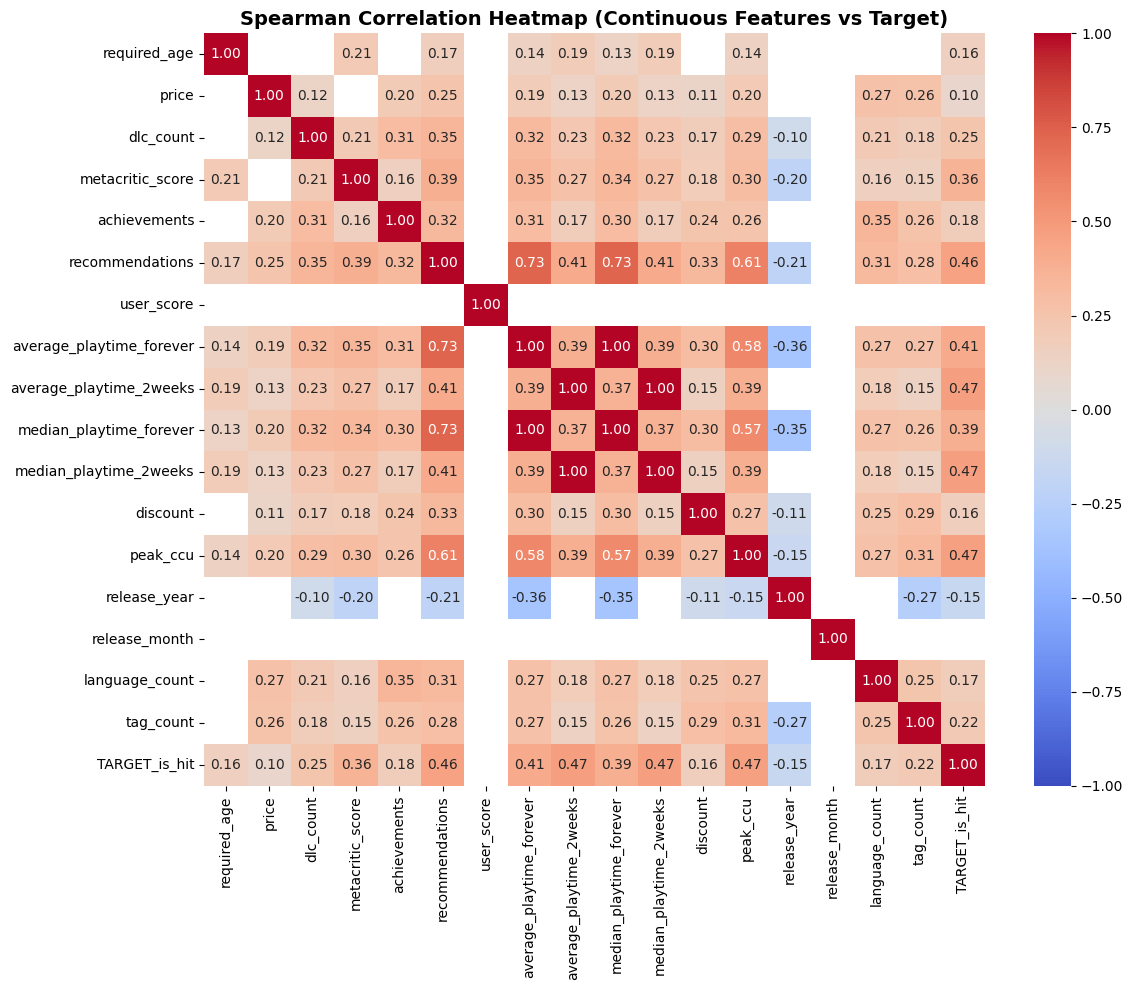

In [ ]:
current_num_cols = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

corr_df = X_train[current_num_cols].copy()
corr_df["TARGET_is_hit"] = y_train

corr_matrix = corr_df.corr(method="spearman")

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    mask=np.abs(corr_matrix) < 0.1,
)
plt.title(
    "Spearman Correlation Heatmap (Continuous Features vs Target)",
    fontweight="bold",
    fontsize=14,
)
plt.tight_layout()
plt.show()

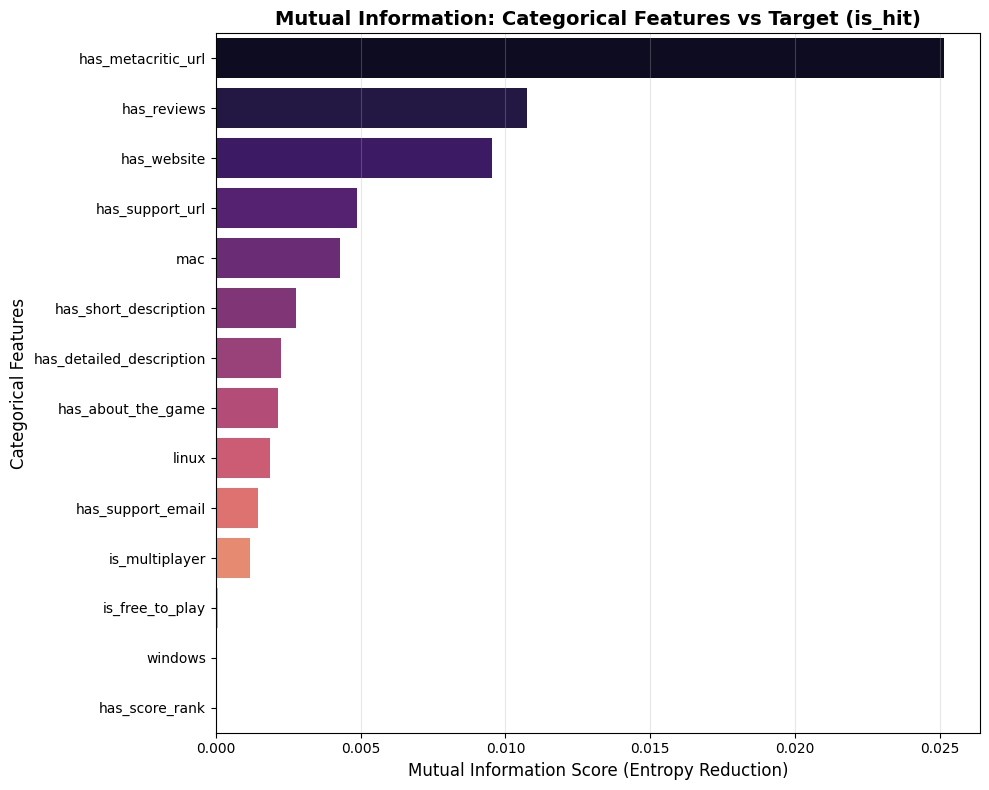


Top 5 Categorical Predictors:
has_metacritic_url    0.025125
has_reviews           0.010749
has_website           0.009530
has_support_url       0.004885
mac                   0.004306
dtype: float64


In [ ]:
cat_features = X_train.select_dtypes(
    exclude=["int64", "float64", "int32", "float32"]
).columns.tolist()

X_cat_prep = X_train[cat_features].copy()

X_cat_prep = X_cat_prep.astype(str).replace(
    {"nan": "Missing", "<NA>": "Missing"}
)

encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X_cat_prep)

mi_scores = mutual_info_classif(
    X_encoded, y_train, discrete_features=True, random_state=42
)

mi_series = pd.Series(mi_scores, index=cat_features).sort_values(
    ascending=False
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=mi_series.values,
    y=mi_series.index,
    palette="magma",
    hue=mi_series.index,
    legend=False,
)

plt.title(
    "Mutual Information: Categorical Features vs Target (is_hit)",
    fontweight="bold",
    fontsize=14,
)
plt.xlabel("Mutual Information Score (Entropy Reduction)", fontsize=12)
plt.ylabel("Categorical Features", fontsize=12)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 5 Categorical Predictors:")
print(mi_series.head(5))

In [ ]:
low_mi_cols = ["windows", "has_score_rank"]

X_train = X_train.drop(
    columns=[col for col in low_mi_cols if col in X_train.columns]
)